<a href="https://colab.research.google.com/github/notwo-prog/ModelosEstocasticosESFM/blob/main/CaminataAleatoria1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminata aleatoria unidimensional

Alumno: Padilla Ramírez Diego Emilio


## Modelo probabilístico

Sea $X_n$ la posición del punto en el tiempo $n$.

En cada paso el punto se mueve una unidad a la derecha o a la izquierda.  
Sean $p$ y $q$ las probabilidades de cada movimiento, tales que

$$
p+q=1.
$$

El movimiento depende únicamente de la posición actual, por lo que la caminata constituye un proceso de Markov.  
Las probabilidades de transición son

$$
P(X_{n+1}=i \mid X_n=j)=
\begin{cases}
p & \text{si } i=j+1 \\
q & \text{si } i=j-1 \\
0 & \text{en otro caso}
\end{cases}
$$

Cumpliéndose la propiedad de Markov:

$$
P(X_{n+1}=x_{n+1}\mid X_1=x_1,\dots,X_n=x_n)
=
P(X_{n+1}=x_{n+1}\mid X_n=x_n).
$$

## Representación mediante variables aleatorias

Podemos escribir la caminata como

$$
X_n = X_0 + \sum_{i=1}^n \xi_i
$$

donde

$$
P(\xi_i=1)=p, \qquad P(\xi_i=-1)=q
$$

y las $\xi_i$ son independientes.

## Esperanza

La esperanza de cada paso es

$$
E[\xi_i]=1\cdot p+(-1)\cdot q=p-q
$$

Entonces

$$
E[X_n]=E[X_0]+\sum_{i=1}^nE[\xi_i]
$$

$$
E[X_n]=X_0+n(p-q)
$$

Tomando $X_0=0$,

$$
E[X_n]=n(p-q)
$$

## Varianza de la caminata

Como

$$
X_n=X_0+\sum_{i=1}^n\xi_i
$$

y las variables son independientes,

$$
\mathrm{Var}(X_n)=\sum_{i=1}^n\mathrm{Var}(\xi_i)
$$

Calculamos primero el segundo momento:

$$
E[\xi_i^2]=1^2p+(-1)^2q=p+q=1
$$

Entonces

$$
\mathrm{Var}(\xi_i)=E[\xi_i^2]-E[\xi_i]^2
$$

$$
\mathrm{Var}(\xi_i)=1-(p-q)^2
$$

Por lo tanto

$$
\mathrm{Var}(X_n)=n\left[1-(p-q)^2\right]
$$

Como $q=1-p$:

$$
(p-q)^2=(2p-1)^2
$$

$$
1-(p-q)^2=1-(2p-1)^2
$$

$$
=1-(4p^2-4p+1)
$$

$$
=4p-4p^2
$$

$$
=4p(1-p)
$$

$$
=4pq
$$

Finalmente

$$
\mathrm{Var}(X_n)=4npq
$$

## Interpretación

- si $p=\tfrac12$ la caminata no tiene deriva y la dispersión crece como $\sqrt{n}$
- si $p>1/2$ tiende a crecer
- si $p<1/2$ tiende a decrecer






p entre 0 y 1: 0.55


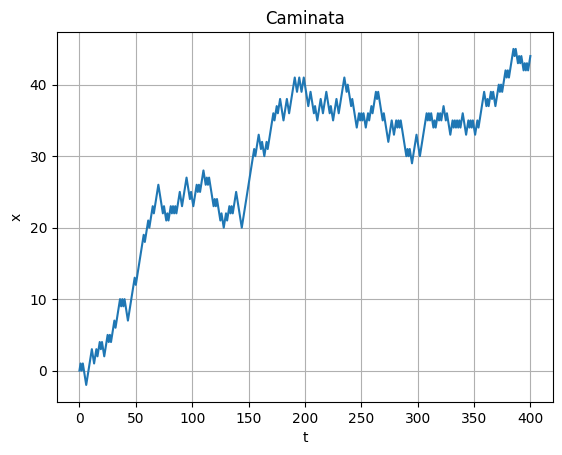

maximo: 45
minimo: -2
pasa por cero: True
xbarra: 40.524
media: 40.000000000000036
varianza simulada: 408.75742399999996
varianza teorica: 396.0


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def caminata(n, p, q, x0=0):
    x = [x0]
    for _ in range(n):
        if np.random.rand() < p:
            x.append(x[-1] + 1)
        else:
            x.append(x[-1] - 1)
    return np.array(x)

n = 400
p = float(input("p entre 0 y 1: "))

if p < 0 or p > 1:
    raise ValueError("p invalida")

q = 1 - p

x = caminata(n, p, q)

plt.plot(x)
plt.title("Caminata")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()
plt.show()

print("maximo:", x.max())
print("minimo:", x.min())
print("pasa por cero:", 0 in x)

r = 3000
finales = np.array([caminata(n, p, q)[-1] for _ in range(r)])

print("xbarra:", finales.mean())
print("media:", n*(p-q))
print("varianza simulada:", finales.var())
print("varianza teorica:", 4*n*p*q)





## Análisis y conclusión

Se implementó un programa que simula una caminata aleatoria donde, dadas las probabilidades $p$ y $q$, se decide en cada paso si el punto avanza o retrocede una unidad. El código además permite observar la trayectoria y verificar si el punto alcanza extremos o regresa al origen.

Al repetir el experimento muchas veces se aprecia que, aunque cada recorrido es distinto, los valores promedio se ajustan a las expresiones teóricas de la media y la varianza. Esto muestra que el comportamiento global no depende de una trayectoria particular sino de la estructura probabilística del proceso.

En general, el modelo puede interpretarse como un sistema de estados donde cada posición depende solo de la anterior, lo cual corresponde a un proceso de Markov. Así, una regla local sencilla produce un comportamiento estadístico regular a gran escala.


